# TFT — Temporal Fusion Transformer sobre Vitales

Implementación custom del **Temporal Fusion Transformer** para clasificación binaria (sepsis/no-sepsis).

Componentes clave del TFT:
- **Variable Selection Network (VSN)**: selección ponderada de variables por instancia
- **LSTM encoder**: captura dependencias temporales a corto plazo
- **Multi-head self-attention**: dependencias de largo alcance en la secuencia
- **Gated Residual Networks (GRN)**: control del flujo de información
- **Cabeza de clasificación**: probabilidad de sepsis

**Input**: ventana de 24h de vitales antes del tiempo de referencia  
**Horizontes**: 6h y 12h antes del onset  
**Salida**: modelos + representaciones del encoder para la red de fusión

In [1]:
import polars as pl
import numpy as np
import json
import pickle
from pathlib import Path
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import matplotlib.pyplot as plt

MIMIC   = Path.home() / "mimic-iv-3.0"
HOSP    = MIMIC / "hosp"
PROC    = Path("../data/processed")
OUT_DIR = Path("../experiments/tft")
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED    = 42
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEQ_LEN = 24   # horas de look-back

torch.manual_seed(SEED)
np.random.seed(SEED)

def log(msg):
    print(f"[{time.strftime('%H:%M:%S')}] {msg}")

print(f"Device: {DEVICE}  |  SEQ_LEN: {SEQ_LEN}h")

Device: cuda  |  SEQ_LEN: 24h


## PASO 1 — Cargar datos

In [2]:
log("Cargando datos ...")

cohort = pl.read_parquet(PROC / "cohort.parquet").select([
    "subject_id", "stay_id", "los_hours", "sepsis",
])
splits = pl.read_parquet(PROC / "splits.parquet").select(["stay_id", "split"])
cohort = cohort.join(splits, on="stay_id", how="left")

# onset_hour desde vitals (ya pre-calculado)
vitals_meta = (
    pl.read_parquet(PROC / "vitals/vitals_hourly.parquet",
                    columns=["stay_id", "onset_hour"])
    .unique(subset=["stay_id"])
)
cohort = cohort.join(vitals_meta, on="stay_id", how="left")

patients = pl.read_csv(
    HOSP / "patients.csv.gz", columns=["subject_id", "gender", "anchor_age"]
).with_columns((pl.col("gender") == "M").cast(pl.Int8).alias("male"))
cohort = cohort.join(
    patients.select(["subject_id", "anchor_age", "male"]),
    on="subject_id", how="left"
)

VITAL_COLS = ["heart_rate", "resp_rate", "spo2", "map", "temp_c",
              "fio2", "gcs_total"]

vitals = pl.read_parquet(
    PROC / "vitals/vitals_hourly.parquet",
    columns=["stay_id", "hours_from_intime"] + VITAL_COLS
)

log(f"Cohorte: {len(cohort):,}  |  Vitales: {vitals.shape}")

[19:49:47] Cargando datos ...
[19:49:47] Cohorte: 74,829  |  Vitales: (7940236, 9)


## PASO 2 — Tiempo de referencia y preparación de secuencias

Para cada stay extraemos la ventana `[ref_hour - SEQ_LEN, ref_hour]` de vitales.  
Padding con ceros si hay menos de SEQ_LEN horas disponibles (inicio de estancia).  
Variables estáticas: `anchor_age`, `male` (normalizadas).

In [3]:
def assign_ref_hour(cohort, horizon, seed):
    rng = np.random.default_rng(seed)
    out = []
    for r in cohort.to_dicts():
        if r["sepsis"] == 1:
            ref = (int(r["onset_hour"]) - horizon) if r["onset_hour"] is not None else None
        else:
            lo, hi = 24, int(r["los_hours"]) - horizon
            ref = int(rng.integers(lo, hi + 1)) if hi >= lo else None
        if ref is not None and ref >= 12:
            r["ref_hour"] = ref
            out.append(r)
    return pl.DataFrame(out)

cohort_6h  = assign_ref_hour(cohort, 6,  SEED)
cohort_12h = assign_ref_hour(cohort, 12, SEED + 1)

print(f"Stays válidos 6h:  {len(cohort_6h):,}")
print(f"Stays válidos 12h: {len(cohort_12h):,}")

Stays válidos 6h:  53,453
Stays válidos 12h: 47,219


In [4]:
# Ajustar scalers solo con datos de train (vitales)
log("Ajustando scalers sobre train ...")

def fit_scalers(cohort_h, vitals, vital_cols, seq_len):
    train_ids = cohort_h.filter(pl.col("split") == "train")["stay_id"].to_list()

    sample = (
        vitals.filter(pl.col("stay_id").is_in(train_ids))
        .select(vital_cols)
        .to_pandas()
        .astype(float)
        .values
    )
    imp = SimpleImputer(strategy="median")
    sample_imp = imp.fit_transform(sample)
    sc = StandardScaler()
    sc.fit(sample_imp)

    # Static: age + male
    static_vals = cohort_h.filter(pl.col("split") == "train") \
                           .select(["anchor_age", "male"]).to_pandas().astype(float).values
    imp_static = SimpleImputer(strategy="median")
    static_imp = imp_static.fit_transform(static_vals)
    sc_static = StandardScaler()
    sc_static.fit(static_imp)

    return imp, sc, imp_static, sc_static

imp6, sc6, imp6_st, sc6_st = fit_scalers(cohort_6h,  vitals, VITAL_COLS, SEQ_LEN)
imp12, sc12, imp12_st, sc12_st = fit_scalers(cohort_12h, vitals, VITAL_COLS, SEQ_LEN)

log("Scalers ajustados.")

[19:49:47] Ajustando scalers sobre train ...


[19:50:04] Scalers ajustados.


## PASO 3 — Dataset PyTorch

In [5]:
class SepsisVitalsDataset(Dataset):
    """
    Pre-extrae todas las secuencias en __init__ como arrays numpy.
    __getitem__ es O(1) — sin filtros Polars por muestra.
    """
    def __init__(self, cohort_h, vitals_df, vital_cols, seq_len,
                 imp, sc, imp_st, sc_st, split_name):
        subset = cohort_h.filter(pl.col("split") == split_name)
        records = subset.select(
            ["stay_id", "ref_hour", "sepsis", "anchor_age", "male"]
        ).to_dicts()

        # Filtrar vitales del split una sola vez y agrupar por stay_id
        split_ids = subset["stay_id"].to_list()
        vitals_split = (
            vitals_df
            .filter(pl.col("stay_id").is_in(split_ids))
            .sort(["stay_id", "hours_from_intime"])
        )
        # Dict stay_id → array numpy [n_horas, n_vitals]
        vitals_by_stay = {}
        for stay_id, grp in vitals_split.group_by("stay_id"):
            vitals_by_stay[stay_id[0]] = (
                grp.select(vital_cols).to_pandas().astype(float).values
            )
        hours_by_stay = {}
        for stay_id, grp in vitals_split.group_by("stay_id"):
            hours_by_stay[stay_id[0]] = grp["hours_from_intime"].to_numpy()

        n = len(records)
        n_vitals = len(vital_cols)
        n_static = 2

        seqs    = np.zeros((n, seq_len, n_vitals), dtype=np.float32)
        statics = np.zeros((n, n_static),          dtype=np.float32)
        labels  = np.zeros(n,                       dtype=np.int64)

        for i, r in enumerate(records):
            stay_id  = r["stay_id"]
            ref_hour = r["ref_hour"]

            if stay_id in vitals_by_stay:
                hours = hours_by_stay[stay_id]
                mask  = (hours >= ref_hour - seq_len) & (hours <= ref_hour)
                win   = vitals_by_stay[stay_id][mask]
                if len(win) > 0:
                    win_imp = imp.transform(win)
                    win_sc  = sc.transform(win_imp).astype(np.float32)
                    n_rows  = min(len(win_sc), seq_len)
                    seqs[i, -n_rows:] = win_sc[-n_rows:]

            static_raw = np.array([[r["anchor_age"] or 0.0, r["male"] or 0.0]])
            statics[i] = sc_st.transform(imp_st.transform(static_raw))[0]
            labels[i]  = r["sepsis"]

        self.seqs    = torch.from_numpy(seqs)
        self.statics = torch.from_numpy(statics)
        self.labels  = torch.from_numpy(labels)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return self.seqs[idx], self.statics[idx], self.labels[idx]


def make_loaders(cohort_h, vitals, vital_cols, seq_len,
                 imp, sc, imp_st, sc_st, batch_size=512):
    loaders = {}
    for split in ["train", "val", "test"]:
        log(f"  Pre-extrayendo secuencias — {split} ...")
        ds = SepsisVitalsDataset(
            cohort_h, vitals, vital_cols, seq_len,
            imp, sc, imp_st, sc_st, split
        )
        loaders[split] = DataLoader(
            ds, batch_size=batch_size,
            shuffle=(split == "train"),
            num_workers=0,   # datos ya en RAM, workers innecesarios
        )
        print(f"    {split}: {len(ds):,} muestras — seqs {tuple(ds.seqs.shape)}")
    return loaders

log("Construyendo dataloaders 6h ...")
loaders_6h  = make_loaders(cohort_6h,  vitals, VITAL_COLS, SEQ_LEN,
                            imp6,  sc6,  imp6_st,  sc6_st)
log("Construyendo dataloaders 12h ...")
loaders_12h = make_loaders(cohort_12h, vitals, VITAL_COLS, SEQ_LEN,
                            imp12, sc12, imp12_st, sc12_st)

[19:50:04] Construyendo dataloaders 6h ...
[19:50:04]   Pre-extrayendo secuencias — train ...


    train: 37,376 muestras — seqs (37376, 24, 7)
[19:50:37]   Pre-extrayendo secuencias — val ...


    val: 8,061 muestras — seqs (8061, 24, 7)
[19:50:44]   Pre-extrayendo secuencias — test ...


    test: 8,016 muestras — seqs (8016, 24, 7)
[19:50:51] Construyendo dataloaders 12h ...
[19:50:51]   Pre-extrayendo secuencias — train ...


    train: 32,992 muestras — seqs (32992, 24, 7)
[19:51:19]   Pre-extrayendo secuencias — val ...


    val: 7,127 muestras — seqs (7127, 24, 7)
[19:51:25]   Pre-extrayendo secuencias — test ...


    test: 7,100 muestras — seqs (7100, 24, 7)


## PASO 4 — Arquitectura TFT

Implementación de los componentes clave del TFT (Lim et al., 2021):  
- **GRN** (Gated Residual Network): bloque base con gate de control del flujo  
- **VSN** (Variable Selection Network): selección ponderada de variables temporales y estáticas  
- **LSTM encoder**: procesa secuencia temporal  
- **Interpretable Multi-Head Attention**: atención compartida por cabeza  
- **Clasificador**: proyección final → logit binario

In [6]:
class GRN(nn.Module):
    """Gated Residual Network."""
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.1):
        super().__init__()
        self.fc1    = nn.Linear(input_dim, hidden_dim)
        self.fc2    = nn.Linear(hidden_dim, output_dim)
        self.gate   = nn.Linear(hidden_dim, output_dim)
        self.skip   = nn.Linear(input_dim, output_dim) if input_dim != output_dim else nn.Identity()
        self.ln     = nn.LayerNorm(output_dim)
        self.drop   = nn.Dropout(dropout)

    def forward(self, x):
        h = F.elu(self.fc1(x))
        h = self.drop(h)
        out  = self.fc2(h)
        gate = torch.sigmoid(self.gate(h))
        return self.ln(gate * out + self.skip(x))


class VSN(nn.Module):
    """Variable Selection Network (temporal o estático)."""
    def __init__(self, n_vars, input_dim, hidden_dim, dropout=0.1):
        super().__init__()
        self.n_vars    = n_vars
        self.var_grns  = nn.ModuleList([
            GRN(input_dim, hidden_dim, hidden_dim, dropout) for _ in range(n_vars)
        ])
        self.weight_grn = GRN(n_vars * input_dim, hidden_dim, n_vars, dropout)

    def forward(self, x):
        # x: [..., n_vars, input_dim]
        flat = x.reshape(*x.shape[:-2], -1)
        weights = torch.softmax(self.weight_grn(flat), dim=-1)   # [..., n_vars]
        processed = torch.stack(
            [grn(x[..., i, :]) for i, grn in enumerate(self.var_grns)], dim=-2
        )  # [..., n_vars, hidden_dim]
        # Suma ponderada
        out = (weights.unsqueeze(-1) * processed).sum(dim=-2)  # [..., hidden_dim]
        return out, weights


class SepsisTFT(nn.Module):
    """
    TFT adaptado para clasificación binaria de sepsis.
    
    Args:
        n_vitals:    número de variables temporales
        n_static:    número de covariables estáticas
        hidden_dim:  dimensión interna
        n_heads:     cabezas de atención
        n_lstm_layers: capas LSTM
        dropout:     tasa de dropout
    """
    def __init__(self, n_vitals=7, n_static=2, hidden_dim=64,
                 n_heads=4, n_lstm_layers=2, dropout=0.1):
        super().__init__()
        self.hidden_dim = hidden_dim

        # Embeddings de entrada (proyección lineal por variable)
        self.vital_embeds  = nn.ModuleList([nn.Linear(1, hidden_dim) for _ in range(n_vitals)])
        self.static_embeds = nn.ModuleList([nn.Linear(1, hidden_dim) for _ in range(n_static)])

        # Variable Selection Networks
        self.vsn_temporal = VSN(n_vitals,  hidden_dim, hidden_dim, dropout)
        self.vsn_static   = VSN(n_static,  hidden_dim, hidden_dim, dropout)

        # Static context → contexto inicial LSTM
        self.static_ctx_h = nn.Linear(hidden_dim, hidden_dim)
        self.static_ctx_c = nn.Linear(hidden_dim, hidden_dim)

        # LSTM encoder
        self.lstm = nn.LSTM(
            input_size=hidden_dim,
            hidden_size=hidden_dim,
            num_layers=n_lstm_layers,
            dropout=dropout if n_lstm_layers > 1 else 0.0,
            batch_first=True,
        )

        # Gated skip connection post-LSTM
        self.post_lstm_grn = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)

        # Multi-head self-attention
        self.attn = nn.MultiheadAttention(
            embed_dim=hidden_dim, num_heads=n_heads,
            dropout=dropout, batch_first=True
        )
        self.post_attn_grn = GRN(hidden_dim, hidden_dim, hidden_dim, dropout)

        # Clasificador (usa último timestep)
        self.classifier = nn.Sequential(
            nn.LayerNorm(hidden_dim),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, seq, static):
        """
        seq:    [B, T, n_vitals]
        static: [B, n_static]
        returns: logit [B], attn_weights [B, T, T]
        """
        B, T, V = seq.shape

        # --- Embeddings temporales ---
        vital_emb = torch.stack(
            [self.vital_embeds[i](seq[..., i:i+1]) for i in range(V)], dim=2
        )  # [B, T, V, hidden_dim]

        # --- Embeddings estáticos ---
        static_emb = torch.stack(
            [self.static_embeds[i](static[..., i:i+1]) for i in range(static.shape[-1])], dim=1
        )  # [B, n_static, hidden_dim]

        # --- VSN estático ---
        static_selected, _ = self.vsn_static(static_emb)  # [B, hidden_dim]

        # --- VSN temporal (aplicado a cada timestep) ---
        temporal_selected, vsn_weights = self.vsn_temporal(vital_emb)  # [B, T, hidden_dim]

        # --- Contexto LSTM desde estáticos ---
        h0 = self.static_ctx_h(static_selected).unsqueeze(0).expand(self.lstm.num_layers, -1, -1).contiguous()
        c0 = self.static_ctx_c(static_selected).unsqueeze(0).expand(self.lstm.num_layers, -1, -1).contiguous()

        # --- LSTM ---
        lstm_out, _ = self.lstm(temporal_selected, (h0, c0))  # [B, T, hidden_dim]
        lstm_out = self.post_lstm_grn(lstm_out)

        # --- Self-attention ---
        attn_out, attn_weights = self.attn(lstm_out, lstm_out, lstm_out)
        attn_out = self.post_attn_grn(attn_out)

        # --- Clasificación en el último timestep ---
        last = attn_out[:, -1, :]   # [B, hidden_dim]
        logit = self.classifier(last).squeeze(-1)  # [B]

        return logit, attn_weights

    def encode(self, seq, static):
        """Devuelve representación del encoder (último timestep) para la red de fusión."""
        with torch.no_grad():
            _, _ = self.forward(seq, static)
        # Reutilizar el hook: forward completo, extraer activación pre-classifier
        B, T, V = seq.shape
        vital_emb = torch.stack(
            [self.vital_embeds[i](seq[..., i:i+1]) for i in range(V)], dim=2
        )
        static_emb = torch.stack(
            [self.static_embeds[i](static[..., i:i+1]) for i in range(static.shape[-1])], dim=1
        )
        static_selected, _ = self.vsn_static(static_emb)
        temporal_selected, _ = self.vsn_temporal(vital_emb)
        h0 = self.static_ctx_h(static_selected).unsqueeze(0).expand(self.lstm.num_layers, -1, -1).contiguous()
        c0 = self.static_ctx_c(static_selected).unsqueeze(0).expand(self.lstm.num_layers, -1, -1).contiguous()
        lstm_out, _ = self.lstm(temporal_selected, (h0, c0))
        lstm_out = self.post_lstm_grn(lstm_out)
        attn_out, _ = self.attn(lstm_out, lstm_out, lstm_out)
        attn_out = self.post_attn_grn(attn_out)
        return attn_out[:, -1, :]   # [B, hidden_dim]


model_params = dict(n_vitals=len(VITAL_COLS), n_static=2,
                    hidden_dim=64, n_heads=4, n_lstm_layers=2, dropout=0.1)
test_model = SepsisTFT(**model_params)
n_params = sum(p.numel() for p in test_model.parameters() if p.requires_grad)
print(f"Parámetros TFT: {n_params:,}")
del test_model

Parámetros TFT: 273,134


## PASO 5 — Entrenamiento

In [7]:
def train_tft(loaders, model_params, pos_weight_val, n_epochs=50, patience=10, lr=1e-3):
    model = SepsisTFT(**model_params).to(DEVICE)
    pos_w = torch.tensor([pos_weight_val], dtype=torch.float32).to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", patience=4, factor=0.5
    )

    best_auroc = 0.0
    best_state = None
    patience_count = 0

    for epoch in range(1, n_epochs + 1):
        # --- Train ---
        model.train()
        total_loss = 0.0
        for seq, static, labels in loaders["train"]:
            seq, static, labels = seq.to(DEVICE), static.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            logits, _ = model(seq, static)
            loss = criterion(logits, labels.float())
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            total_loss += loss.item()

        # --- Val ---
        model.eval()
        val_probs, val_labels = [], []
        with torch.no_grad():
            for seq, static, labels in loaders["val"]:
                seq, static = seq.to(DEVICE), static.to(DEVICE)
                logits, _ = model(seq, static)
                val_probs.extend(torch.sigmoid(logits).cpu().numpy())
                val_labels.extend(labels.numpy())

        val_auroc = roc_auc_score(val_labels, val_probs)
        scheduler.step(val_auroc)

        if epoch % 5 == 0:
            print(f"  Epoch {epoch:3d} | loss={total_loss/len(loaders['train']):.4f} "
                  f"| val AUROC={val_auroc:.4f}")

        if val_auroc > best_auroc:
            best_auroc = val_auroc
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            patience_count = 0
        else:
            patience_count += 1
            if patience_count >= patience:
                print(f"  Early stopping en epoch {epoch}")
                break

    model.load_state_dict(best_state)
    print(f"  Mejor val AUROC: {best_auroc:.4f}")
    return model


def get_pos_weight(loaders):
    all_labels = []
    for _, _, labels in loaders["train"]:
        all_labels.extend(labels.numpy())
    arr = np.array(all_labels)
    return float((arr == 0).sum() / max((arr == 1).sum(), 1))

pw6  = get_pos_weight(loaders_6h)
pw12 = get_pos_weight(loaders_12h)
print(f"pos_weight 6h={pw6:.2f}  12h={pw12:.2f}")

log("Entrenando TFT — horizonte 6h ...")
tft_6h  = train_tft(loaders_6h,  model_params, pw6,  n_epochs=50, patience=10)

log("Entrenando TFT — horizonte 12h ...")
tft_12h = train_tft(loaders_12h, model_params, pw12, n_epochs=50, patience=10)

pos_weight 6h=11.27  12h=11.09
[19:51:32] Entrenando TFT — horizonte 6h ...


  Epoch   5 | loss=0.8545 | val AUROC=0.8304


  Epoch  10 | loss=0.8279 | val AUROC=0.8335


  Epoch  15 | loss=0.7839 | val AUROC=0.8331


  Early stopping en epoch 19
  Mejor val AUROC: 0.8371
[19:51:58] Entrenando TFT — horizonte 12h ...


...

  Epoch  10 | loss=0.8342 | val AUROC=0.8138


  Epoch  15 | loss=0.7880 | val AUROC=0.8192


  Epoch  20 | loss=0.7490 | val AUROC=0.8054


  Epoch  25 | loss=0.6684 | val AUROC=0.7891


  Early stopping en epoch 26
  Mejor val AUROC: 0.8232


## PASO 6 — Evaluación

In [8]:
def evaluate_tft(model, loader, label=""):
    model.eval()
    probs, labels_all = [], []
    with torch.no_grad():
        for seq, static, labels in loader:
            seq, static = seq.to(DEVICE), static.to(DEVICE)
            logits, _ = model(seq, static)
            probs.extend(torch.sigmoid(logits).cpu().numpy())
            labels_all.extend(labels.numpy())

    probs = np.array(probs)
    labels_all = np.array(labels_all)

    auroc = roc_auc_score(labels_all, probs)
    auprc = average_precision_score(labels_all, probs)
    fpr, tpr, _ = roc_curve(labels_all, probs)
    mask = fpr <= 0.10
    sens = float(tpr[mask].max()) if mask.any() else 0.0

    print(f"  {label:<8}  AUROC={auroc:.4f}  AUPRC={auprc:.4f}  Sens@Spec90={sens:.4f}")
    return {"auroc": round(auroc, 4), "auprc": round(auprc, 4), "sens_at_spec90": round(sens, 4)}

print("=" * 60)
print("  HORIZONTE 6h")
print("=" * 60)
r6_val  = evaluate_tft(tft_6h,  loaders_6h["val"],  "Val")
r6_test = evaluate_tft(tft_6h,  loaders_6h["test"], "Test")

print("\n" + "=" * 60)
print("  HORIZONTE 12h")
print("=" * 60)
r12_val  = evaluate_tft(tft_12h, loaders_12h["val"],  "Val")
r12_test = evaluate_tft(tft_12h, loaders_12h["test"], "Test")

print("\n  Baselines (referencia):")
print("  XGBoost  6h  AUROC=0.8224  AUPRC=0.4657  Sens@Spec90=0.5643")
print("  XGBoost 12h  AUROC=0.7949  AUPRC=0.4300  Sens@Spec90=0.4904")

  HORIZONTE 6h
  Val       AUROC=0.8371  AUPRC=0.5878  Sens@Spec90=0.6108


  Test      AUROC=0.8603  AUPRC=0.6418  Sens@Spec90=0.6536

  HORIZONTE 12h
  Val       AUROC=0.8232  AUPRC=0.5766  Sens@Spec90=0.5981


  Test      AUROC=0.8679  AUPRC=0.6668  Sens@Spec90=0.6667

  Baselines (referencia):
  XGBoost  6h  AUROC=0.8224  AUPRC=0.4657  Sens@Spec90=0.5643
  XGBoost 12h  AUROC=0.7949  AUPRC=0.4300  Sens@Spec90=0.4904


## PASO 7 — Visualización de atención temporal

Los pesos de atención muestran qué timesteps influyen más en la predicción.  
Visualizamos el promedio sobre las muestras sépticas del test set.

[19:52:28] Calculando pesos de atención en test set (6h) ...


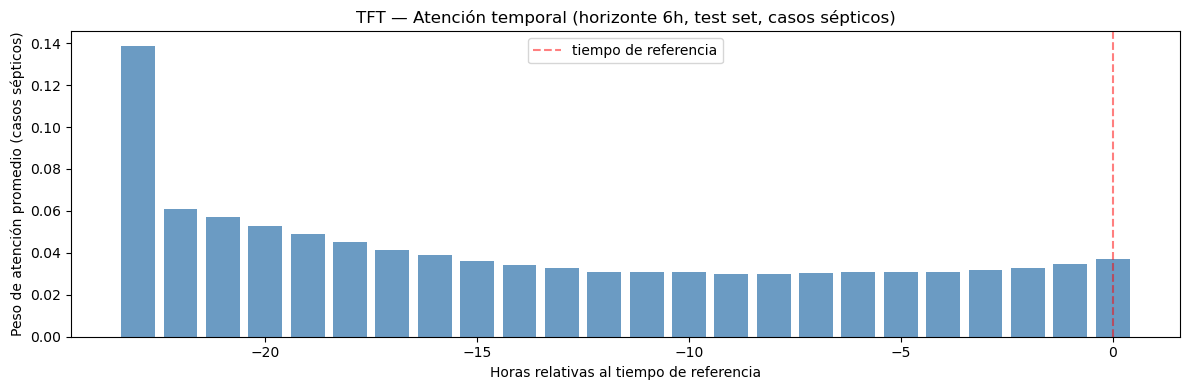

[19:52:29] Guardada: ../experiments/tft/tft_attention_6h.png


In [9]:
log("Calculando pesos de atención en test set (6h) ...")

tft_6h.eval()
attn_sepsis = []
with torch.no_grad():
    for seq, static, labels in loaders_6h["test"]:
        seq, static = seq.to(DEVICE), static.to(DEVICE)
        _, attn_w = tft_6h(seq, static)   # attn_w: [B, T, T]
        mask_sep = labels.numpy() == 1
        if mask_sep.any():
            # Último timestep (predicción) vs todos los timesteps pasados
            attn_last = attn_w[mask_sep, -1, :].cpu().numpy()  # [n_sep, T]
            attn_sepsis.append(attn_last)

attn_mean = np.concatenate(attn_sepsis, axis=0).mean(axis=0)  # [T]
hours_ago  = np.arange(-SEQ_LEN + 1, 1)  # -23 ... 0

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(hours_ago, attn_mean, color="steelblue", alpha=0.8)
ax.set_xlabel("Horas relativas al tiempo de referencia")
ax.set_ylabel("Peso de atención promedio (casos sépticos)")
ax.set_title("TFT — Atención temporal (horizonte 6h, test set, casos sépticos)")
ax.axvline(0, color="red", linestyle="--", alpha=0.5, label="tiempo de referencia")
ax.legend()
fig.tight_layout()
fig.savefig(OUT_DIR / "tft_attention_6h.png", dpi=150, bbox_inches="tight")
plt.show()
log(f"Guardada: {OUT_DIR / 'tft_attention_6h.png'}")

## PASO 8 — Guardar modelos y representaciones del encoder

Se guardan tanto los pesos del modelo completo (para inferencia) como las  
representaciones del encoder sobre el test set (para la red de fusión).

In [10]:
# Guardar pesos
torch.save(tft_6h.state_dict(),  OUT_DIR / "tft_6h.pt")
torch.save(tft_12h.state_dict(), OUT_DIR / "tft_12h.pt")

# Guardar scalers
with open(OUT_DIR / "scalers_6h.pkl",  "wb") as f:
    pickle.dump((imp6, sc6, imp6_st, sc6_st), f)
with open(OUT_DIR / "scalers_12h.pkl", "wb") as f:
    pickle.dump((imp12, sc12, imp12_st, sc12_st), f)

# Guardar model_params (necesario para reconstruir la arquitectura)
with open(OUT_DIR / "model_params.json", "w") as f:
    json.dump(model_params, f, indent=2)

# Resultados
results = {
    "6h":  {"val": r6_val,  "test": r6_test},
    "12h": {"val": r12_val, "test": r12_test},
    "architecture": model_params,
    "seq_len": SEQ_LEN,
    "n_vitals": len(VITAL_COLS),
    "vital_cols": VITAL_COLS,
}
with open(OUT_DIR / "results.json", "w") as f:
    json.dump(results, f, indent=2)

print(json.dumps(results, indent=2))
log(f"Completado — modelos en {OUT_DIR}/")

{
  "6h": {
    "val": {
      "auroc": 0.8371,
      "auprc": 0.5878,
      "sens_at_spec90": 0.6108
    },
    "test": {
      "auroc": 0.8603,
      "auprc": 0.6418,
      "sens_at_spec90": 0.6536
    }
  },
  "12h": {
    "val": {
      "auroc": 0.8232,
      "auprc": 0.5766,
      "sens_at_spec90": 0.5981
    },
    "test": {
      "auroc": 0.8679,
      "auprc": 0.6668,
      "sens_at_spec90": 0.6667
    }
  },
  "architecture": {
    "n_vitals": 7,
    "n_static": 2,
    "hidden_dim": 64,
    "n_heads": 4,
    "n_lstm_layers": 2,
    "dropout": 0.1
  },
  "seq_len": 24,
  "n_vitals": 7,
  "vital_cols": [
    "heart_rate",
    "resp_rate",
    "spo2",
    "map",
    "temp_c",
    "fio2",
    "gcs_total"
  ]
}
[19:52:29] Completado — modelos en ../experiments/tft/
